# Media-spend variation summary

In [2]:
import pandas as pd


In [3]:
# Load the dataset
DATA_PATH = '/content/gold_model_dataset (25) (1).csv'
df = pd.read_csv(DATA_PATH)

# Media-spend columns
spend_columns = [
    'Network_TV_Spend',
    'Cable_TV_Spend',
    'Digital_Spend'
]

In [4]:

# Calculate summary statistics
spend_summary = (
    df[spend_columns]
    .agg(['count', 'mean', 'std', 'min', 'max'])
    .T
    .reset_index()
    .rename(columns={
        'index': 'Channel',
        'count': 'Observations',
        'mean': 'Mean_Spend',
        'std': 'Standard_Deviation',
        'min': 'Minimum_Spend',
        'max': 'Maximum_Spend'
    })
)

In [5]:

# Add spending range
spend_summary['Spend_Range'] = (
    spend_summary['Maximum_Spend']
    - spend_summary['Minimum_Spend']
)

In [6]:
# Add coefficient of variation:
# SD relative to the channel's average spending
spend_summary['Coefficient_of_Variation'] = (
    spend_summary['Standard_Deviation']
    / spend_summary['Mean_Spend']
)

In [7]:
# Format a display copy
display_summary = spend_summary.copy()

currency_columns = [
    'Mean_Spend',
    'Standard_Deviation',
    'Minimum_Spend',
    'Maximum_Spend',
    'Spend_Range'
]


In [8]:
display_summary['Observations'] = (
    display_summary['Observations']
    .astype(int)
)

display_summary['Coefficient_of_Variation'] = (
    display_summary['Coefficient_of_Variation']
    .map(lambda value: f'{value:.1%}')
)

display(display_summary)

,Channel,Observations,Mean_Spend,Standard_Deviation,Minimum_Spend,Maximum_Spend,Spend_Range,Coefficient_of_Variation
0,Network_TV_Spend,420,10880.966706,6464.818974,1737.959827,29201.760073,27463.800247,59.4%
1,Cable_TV_Spend,420,10774.131347,6045.806685,2158.075740,27829.401203,25671.325463,56.1%
2,Digital_Spend,420,11723.257146,5691.947200,2039.800603,27665.920853,25626.120250,48.6%


In [9]:
# %% 1 - Install packages and import libraries

!pip install -q pymc arviz

import os
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Model variables
TARGET = "Revenue"

SPEND = [
    "Network_TV_Spend",
    "Cable_TV_Spend",
    "Digital_Spend"
]

CHANNELS = [
    "Network TV",
    "Cable TV",
    "Digital"
]

GROUPS = ["Show", "Season"]

# Modeling settings
TEST_WEEKS = 3
MAX_LAG = 8

# MCMC settings
DRAWS = 1000
TUNE = 1500
CHAINS = 4
CORES = min(4, os.cpu_count() or 1)

print("PyMC version:", pm.__version__)
print("Target variable:", TARGET)
print("Channels:", CHANNELS)

PyMC version: 5.28.5
Target variable: Revenue
Channels: ['Network TV', 'Cable TV', 'Digital']


#Load and sort the data

In [10]:
# Convert Air_Date from text to a proper date
df["Air_Date"] = pd.to_datetime(
    df["Air_Date"],
    errors="raise"
)

# Adstock depends on the correct chronological order
df = df.sort_values(
    ["Show", "Season", "Week_Number", "Air_Date"]
).reset_index(drop=True)

# Confirm the required columns exist
required_columns = (
    GROUPS
    + ["Week_Number", "Air_Date", "Episode_Type"]
    + ["Holiday", "LeadIn_Bonus", TARGET]
    + SPEND
)

missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

print("Dataset shape:", df.shape)
print("Number of shows:", df["Show"].nunique())
print(
    "Number of show-season groups:",
    df.groupby(GROUPS).ngroups
)

display(df.head())

Dataset shape: (420, 14)
Number of shows: 8
Number of show-season groups: 28


,Show,Season,Week_Number,Air_Date,Episode_Number,Episode_Type,Network_TV_Spend,Cable_TV_Spend,Digital_Spend,Impressions,True_Viewership,Revenue,Holiday,LeadIn_Bonus
0,Show1,1,1,2020-09-06,0,PreLaunch,4028.297704,12084.893113,10070.744261,43639891,117856.380040,82590.005714,0,0
1,Show1,1,2,2020-09-13,0,PreLaunch,4854.153125,14562.459375,12135.382813,52586659,129214.055887,88792.032857,0,0
2,Show1,1,3,2020-09-20,0,PreLaunch,5370.453364,16111.360093,13426.133411,58179911,171609.757399,121836.521429,0,0
3,Show1,1,4,2020-09-27,0,PreLaunch,7619.321690,22857.965070,19048.304225,82542651,178971.843013,124396.604286,0,0
4,Show1,1,5,2020-10-04,0,PreLaunch,7133.216268,21399.648804,17833.040670,77276510,192167.775786,131526.194286,0,0


#Check group structure and create the time-based split

In [11]:
# %% 3 - Group structure and chronological train/test split

TEST_WEEKS = 3

# Position of every row inside its show-season
position_in_group = df.groupby(GROUPS).cumcount()

# Total observations available for that show-season
group_size = df.groupby(GROUPS)["Week_Number"].transform("size")

# Keep the final three observations from every show-season for testing
train_mask = (
    position_in_group < group_size - TEST_WEEKS
).to_numpy()

test_mask = ~train_mask

# Numeric row locations needed later
train_idx = np.flatnonzero(train_mask)
test_idx = np.flatnonzero(test_mask)

# Verify the split within each show-season
split_check = (
    df.assign(
        Split=np.where(train_mask, "Train", "Test")
    )
    .groupby(GROUPS + ["Split"])
    .size()
    .unstack(fill_value=0)
)

print("Total rows:", len(df))
print("Training rows:", train_mask.sum())
print("Testing rows:", test_mask.sum())

display(split_check)

Total rows: 420
Training rows: 336
Testing rows: 84


Split         Test  Train
Show  Season             
Show1 1          3     12
      2          3     12
      3          3     12
      4          3     12
      5          3     12
Show2 1          3     12
      2          3     12
      3          3     12
      4          3     12
      5          3     12
Show3 1          3     12
      2          3     12
      3          3     12
      4          3     12
      5          3     12
Show4 1          3     12
      2          3     12
      3          3     12
      4          3     12
      5          3     12
Show5 1          3     12
      2          3     12
Show6 1          3     12
      2          3     12
Show7 1          3     12
      2          3     12
Show8 1          3     12
      2          3     12

#Create hierarchical indexes and control variables

In [12]:
# %% 4 - Hierarchical indexes and control variables

from sklearn.preprocessing import StandardScaler

# --------------------------------------------------
# 1. Create a numeric index for each show
# --------------------------------------------------

show_levels = pd.Index(
    sorted(df["Show"].unique()),
    name="show"
)

show_lookup = {
    show: index
    for index, show in enumerate(show_levels)
}

show_idx = (
    df["Show"]
    .map(show_lookup)
    .to_numpy(dtype="int32")
)

# --------------------------------------------------
# 2. Create a numeric index for each show-season
# --------------------------------------------------

show_season_label = (
    df["Show"].astype(str)
    + " | Season "
    + df["Season"].astype(str)
)

show_season_levels = pd.Index(
    show_season_label.drop_duplicates(),
    name="show_season"
)

show_season_lookup = {
    group: index
    for index, group in enumerate(show_season_levels)
}

show_season_idx = (
    show_season_label
    .map(show_season_lookup)
    .to_numpy(dtype="int32")
)

# Connect every show-season back to its parent show
group_to_show = (
    df.assign(show_season_label=show_season_label)
    .drop_duplicates("show_season_label")
    .set_index("show_season_label")["Show"]
    .reindex(show_season_levels)
    .map(show_lookup)
    .to_numpy(dtype="int32")
)

# --------------------------------------------------
# 3. Convert episode type into dummy variables
# --------------------------------------------------

episode_dummies = pd.get_dummies(
    df["Episode_Type"],
    prefix="episode",
    dtype=float
)

# Regular episode becomes the reference category
episode_dummies = episode_dummies.drop(
    columns=["episode_Regular"],
    errors="ignore"
)

# --------------------------------------------------
# 4. Combine the control variables
# --------------------------------------------------

controls_raw = pd.concat(
    [
        df[
            [
                "Holiday",
                "LeadIn_Bonus",
                "Week_Number"
            ]
        ].astype(float),

        episode_dummies
    ],
    axis=1
)

CONTROL_NAMES = controls_raw.columns.tolist()

# --------------------------------------------------
# 5. Scale controls using training data only
# --------------------------------------------------

control_scaler = StandardScaler()

control_scaler.fit(
    controls_raw.loc[train_mask]
)

X_controls = control_scaler.transform(
    controls_raw
).astype(float)

# --------------------------------------------------
# 6. Display the resulting structure
# --------------------------------------------------

print("Number of shows:", len(show_levels))
print("Number of show-season groups:", len(show_season_levels))
print("Control variables:", CONTROL_NAMES)
print("Control matrix shape:", X_controls.shape)

display(controls_raw.head())

Number of shows: 8
Number of show-season groups: 28
Control variables: ['Holiday', 'LeadIn_Bonus', 'Week_Number', 'episode_Finale', 'episode_PreLaunch', 'episode_Premiere']
Control matrix shape: (420, 6)


,Holiday,LeadIn_Bonus,Week_Number,episode_Finale,episode_PreLaunch,episode_Premiere
0,0.0,0.0,1.0,0.0,1.0,0.0
1,0.0,0.0,2.0,0.0,1.0,0.0
2,0.0,0.0,3.0,0.0,1.0,0.0
3,0.0,0.0,4.0,0.0,1.0,0.0
4,0.0,0.0,5.0,0.0,1.0,0.0


#Scale the target and media spending

In [13]:
# %% 5 - Scale target and media spending

# --------------------------------------------------
# 1. Prepare the target variable
# --------------------------------------------------

y_raw = df[TARGET].to_numpy(dtype=float)

# Calculate scaling values using training data only
y_mean = y_raw[train_mask].mean()
y_sd = y_raw[train_mask].std()

# Standardized target used by the Bayesian model
y = (y_raw - y_mean) / y_sd

# --------------------------------------------------
# 2. Prepare media spending
# --------------------------------------------------

spend_raw = df[SPEND].to_numpy(dtype=float)

# Use each channel's training P95 as its scale
spend_scale = np.quantile(
    spend_raw[train_mask],
    0.95,
    axis=0
)

# Spending remains positive; it is not centered around zero
spend_scaled = spend_raw / spend_scale

# --------------------------------------------------
# 3. Calculate historical modeling boundaries
# --------------------------------------------------

spend_p05 = np.quantile(
    spend_raw[train_mask],
    0.05,
    axis=0
)

spend_p95 = np.quantile(
    spend_raw[train_mask],
    0.95,
    axis=0
)

spend_limits = pd.DataFrame({
    "Channel": CHANNELS,
    "Training_Min": spend_raw[train_mask].min(axis=0),
    "Training_P05": spend_p05,
    "Training_Median": np.median(
        spend_raw[train_mask],
        axis=0
    ),
    "Training_P95": spend_p95,
    "Training_Max": spend_raw[train_mask].max(axis=0),
    "Scaling_Value": spend_scale
})

print(f"Training {TARGET} mean: {y_mean:,.2f}")
print(f"Training {TARGET} SD: {y_sd:,.2f}")
print("Scaled target mean:", round(y[train_mask].mean(), 4))
print("Scaled target SD:", round(y[train_mask].std(), 4))

display(spend_limits.round(2))

Training Revenue mean: 86,495.28
Training Revenue SD: 45,107.70
Scaled target mean: 0.0
Scaled target SD: 1.0


,Channel,Training_Min,Training_P05,Training_Median,Training_P95,Training_Max,Scaling_Value
0,Network TV,1737.96,2784.71,8829.18,22920.11,29201.76,22920.11
1,Cable TV,2158.08,2941.61,8449.25,23070.63,27829.40,23070.63
2,Digital,2039.80,3206.88,10014.65,22127.59,27665.92,22127.59


In [14]:
# %% 6 - Create channel-specific lag histories for adstock

MAX_LAG = 8

def make_lag_tensor(
    frame,
    media_values,
    group_columns,
    max_lag
):
    """
    Create:
    1. Lagged media spending
    2. Indicators showing which lags are available
    """

    number_of_rows = len(frame)
    number_of_channels = media_values.shape[1]

    # Shape:
    # rows × channels × lags
    lagged = np.zeros(
        (
            number_of_rows,
            number_of_channels,
            max_lag + 1
        ),
        dtype=float
    )

    # Shape:
    # rows × lags
    valid = np.zeros(
        (
            number_of_rows,
            max_lag + 1
        ),
        dtype=float
    )

    # Process each show-season separately
    for _, row_indexes in frame.groupby(
        group_columns,
        sort=False
    ).groups.items():

        indexes = np.asarray(
            list(row_indexes),
            dtype=int
        )

        for local_week, current_row in enumerate(indexes):

            available_lags = min(
                local_week,
                max_lag
            ) + 1

            for lag in range(available_lags):

                previous_row = indexes[local_week - lag]

                lagged[current_row, :, lag] = (
                    media_values[previous_row, :]
                )

                valid[current_row, lag] = 1.0

    return lagged, valid


lagged_spend, valid_lags = make_lag_tensor(
    frame=df,
    media_values=spend_scaled,
    group_columns=GROUPS,
    max_lag=MAX_LAG
)

lag_numbers = np.arange(
    MAX_LAG + 1,
    dtype=float
)

print(
    "Lag tensor shape:",
    lagged_spend.shape
)

print(
    "Valid-lag matrix shape:",
    valid_lags.shape
)

print(
    "First observation's valid lags:",
    valid_lags[0].astype(int)
)

print(
    "Final observation of the first show-season:",
    valid_lags[14].astype(int)
)

Lag tensor shape: (420, 3, 9)
Valid-lag matrix shape: (420, 9)
First observation's valid lags: [1 0 0 0 0 0 0 0 0]
Final observation of the first show-season: [1 1 1 1 1 1 1 1 1]


#Build the hierarchical Bayesian model

In [15]:
# %% 7 - Build the hierarchical Bayesian MMM

# Labels used in posterior output
coords = {
    "obs": np.arange(len(df)),
    "train_obs": np.arange(len(train_idx)),
    "channel": CHANNELS,
    "show": show_levels.tolist(),
    "show_season": show_season_levels.tolist(),
    "control": CONTROL_NAMES,
    "lag": np.arange(MAX_LAG + 1)
}

with pm.Model(coords=coords) as mmm:

    # --------------------------------------------------
    # 1. Add prepared data to the model
    # --------------------------------------------------

    lagged_data = pm.Data(
        "lagged_spend",
        lagged_spend,
        dims=("obs", "channel", "lag")
    )

    valid_lag_data = pm.Data(
        "valid_lags",
        valid_lags,
        dims=("obs", "lag")
    )

    lag_number_data = pm.Data(
        "lag_numbers",
        lag_numbers,
        dims="lag"
    )

    control_data = pm.Data(
        "X_controls",
        X_controls,
        dims=("obs", "control")
    )

    show_index_data = pm.Data(
        "show_index",
        show_idx,
        dims="obs"
    )

    show_season_index_data = pm.Data(
        "show_season_index",
        show_season_idx,
        dims="obs"
    )

    # --------------------------------------------------
    # 2. Hierarchical baseline
    # --------------------------------------------------

    # Overall baseline across the dataset
    intercept_global = pm.Normal(
        "intercept_global",
        mu=0,
        sigma=1
    )

    # Amount shows are allowed to differ
    sd_show = pm.HalfNormal(
        "sd_show",
        sigma=0.7
    )

    z_show = pm.Normal(
        "z_show",
        mu=0,
        sigma=1,
        dims="show"
    )

    intercept_show = pm.Deterministic(
        "intercept_show",
        intercept_global + sd_show * z_show,
        dims="show"
    )

    # Amount seasons within shows are allowed to differ
    sd_show_season = pm.HalfNormal(
        "sd_show_season",
        sigma=0.5
    )

    z_show_season = pm.Normal(
        "z_show_season",
        mu=0,
        sigma=1,
        dims="show_season"
    )

    intercept_show_season = pm.Deterministic(
        "intercept_show_season",
        intercept_show[group_to_show]
        + sd_show_season * z_show_season,
        dims="show_season"
    )

    # --------------------------------------------------
    # 3. Geometric adstock
    # --------------------------------------------------

    # Retention rate for each channel
    alpha = pm.Beta(
        "alpha",
        alpha=2,
        beta=2,
        dims="channel"
    )

    # alpha^lag creates geometric decay weights
    adstock_weights = (
        alpha[:, None]
        ** lag_number_data[None, :]
    )

    adstock_numerator = pt.sum(
        lagged_data
        * adstock_weights[None, :, :],
        axis=2
    )

    adstock_denominator = pt.sum(
        valid_lag_data[:, None, :]
        * adstock_weights[None, :, :],
        axis=2
    )

    adstocked_media = (
        adstock_numerator
        / adstock_denominator
    )

    # --------------------------------------------------
    # 4. Hill/reach saturation
    # --------------------------------------------------

    # Spend level where a channel reaches 50%
    # of its modeled maximum response
    half_saturation = pm.LogNormal(
        "half_saturation",
        mu=np.log(0.5),
        sigma=0.6,
        dims="channel"
    )

    saturated_media = (
        adstocked_media
        / (
            adstocked_media
            + half_saturation[None, :]
        )
    )

    # --------------------------------------------------
    # 5. Hierarchical media coefficients
    # --------------------------------------------------

    # Global channel effects are positive
    log_beta_global = pm.Normal(
        "log_beta_global",
        mu=np.log(0.30),
        sigma=0.7,
        dims="channel"
    )

    beta_global = pm.Deterministic(
        "beta_global",
        pt.exp(log_beta_global),
        dims="channel"
    )

    # Shows can respond differently to each channel
    sd_log_beta_show = pm.HalfNormal(
        "sd_log_beta_show",
        sigma=0.35,
        dims="channel"
    )

    z_beta_show = pm.Normal(
        "z_beta_show",
        mu=0,
        sigma=1,
        dims=("show", "channel")
    )

    beta_show = pm.Deterministic(
        "beta_show",
        pt.exp(
            log_beta_global[None, :]
            + sd_log_beta_show[None, :]
            * z_beta_show
        ),
        dims=("show", "channel")
    )

    # --------------------------------------------------
    # 6. Control-variable coefficients
    # --------------------------------------------------

    beta_controls = pm.Normal(
        "beta_controls",
        mu=0,
        sigma=0.5,
        dims="control"
    )

    # --------------------------------------------------
    # 7. Expected revenue
    # --------------------------------------------------

    media_effect = pt.sum(
        saturated_media
        * beta_show[show_index_data, :],
        axis=1
    )

    mu_all = pm.Deterministic(
        "mu_all",
        intercept_show_season[
            show_season_index_data
        ]
        + media_effect
        + pt.dot(
            control_data,
            beta_controls
        ),
        dims="obs"
    )

    # --------------------------------------------------
    # 8. Likelihood
    # --------------------------------------------------

    sigma = pm.HalfNormal(
        "sigma",
        sigma=0.5
    )

    revenue_likelihood = pm.Normal(
        "revenue_likelihood",
        mu=mu_all[train_idx],
        sigma=sigma,
        observed=y[train_idx],
        dims="train_obs"
    )

print("Hierarchical Bayesian MMM created successfully.")
print(mmm)

Hierarchical Bayesian MMM created successfully.


#Check whether the priors are plausible

Observed training revenue range:
$23,264 to $181,578

Prior-predictive revenue:


,Revenue
P05,-19147.92
Median,113413.62
P95,251025.33
Minimum,-292023.78
Maximum,536118.12


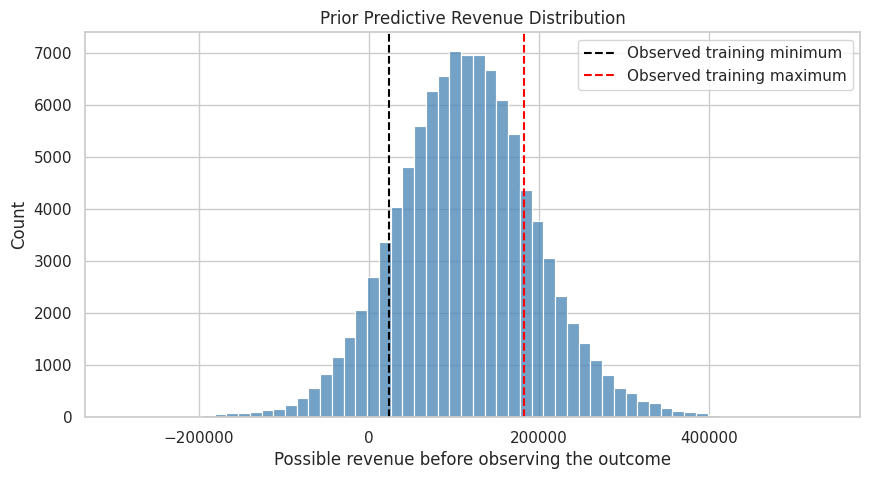

In [16]:
# %% 8 - Prior predictive check

import inspect

with mmm:

    # PyMC versions use either "draws" or "samples"
    prior_argument = (
        "draws"
        if "draws" in inspect.signature(
            pm.sample_prior_predictive
        ).parameters
        else "samples"
    )

    prior_idata = pm.sample_prior_predictive(
        **{prior_argument: 300},
        random_seed=SEED
    )


# --------------------------------------------------
# Handle both newer and older PyMC/ArviZ versions
# --------------------------------------------------

prior_group = prior_idata.prior_predictive

if hasattr(prior_group, "dataset"):
    prior_group = prior_group.dataset

prior_scaled = (
    prior_group["revenue_likelihood"]
    .values
    .reshape(-1)
)

# Convert standardized predictions back to dollars
prior_revenue = (
    y_mean
    + y_sd * prior_scaled
)

# --------------------------------------------------
# Summarize prior predictions
# --------------------------------------------------

prior_summary = pd.Series({
    "P05": np.quantile(prior_revenue, 0.05),
    "Median": np.quantile(prior_revenue, 0.50),
    "P95": np.quantile(prior_revenue, 0.95),
    "Minimum": prior_revenue.min(),
    "Maximum": prior_revenue.max()
})

print("Observed training revenue range:")
print(
    f"${y_raw[train_mask].min():,.0f} "
    f"to ${y_raw[train_mask].max():,.0f}"
)

print("\nPrior-predictive revenue:")
display(
    prior_summary
    .to_frame("Revenue")
    .round(2)
)

# --------------------------------------------------
# Plot prior-predictive outcomes
# --------------------------------------------------

plt.figure(figsize=(10, 5))

sns.histplot(
    prior_revenue,
    bins=60,
    color="steelblue"
)

plt.axvline(
    y_raw[train_mask].min(),
    color="black",
    linestyle="--",
    label="Observed training minimum"
)

plt.axvline(
    y_raw[train_mask].max(),
    color="red",
    linestyle="--",
    label="Observed training maximum"
)

plt.title("Prior Predictive Revenue Distribution")
plt.xlabel("Possible revenue before observing the outcome")
plt.ylabel("Count")
plt.legend()

plt.show()

#Black line: lowest observed training revenue.
#Red line: highest observed training revenue.
#Blue distribution: revenue values allowed by the priors before fitting.
#Most assumed values appear reasonably close to the observed revenue range.
#The priors also permit values outside that range, giving the model flexibility.
#The maximum around $536,000 is possible but relatively rare.

In [18]:
# %% GPU setup

!pip install -q numpyro

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.8/394.8 kB 16.9 MB/s eta 0:00:00


In [19]:
import jax

print("JAX backend:", jax.default_backend())
print("JAX devices:", jax.devices())

JAX backend: gpu
JAX devices: [CudaDevice(id=0)]


#Run MCMC and estimate the posterior distributions

In [20]:
# %% 9 - GPU MCMC using JAX/NumPyro

from pymc.sampling.jax import sample_numpyro_nuts

with mmm:

    idata = sample_numpyro_nuts(
        draws=1000,
        tune=2000,
        chains=4,
        target_accept=0.98,
        random_seed=SEED,
        chain_method="vectorized",
        postprocessing_backend="cpu"
    )

print("GPU MCMC sampling completed.")

sample: 100%|██████████| 3000/3000 [12:19<00:00,  4.05it/s]
ERROR:pymc.stats.convergence:There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


GPU MCMC sampling completed.


In [21]:
# Preserve this posterior before trying anything else
idata_098 = idata

idata_098.to_netcdf(
    "hierarchical_mmm_target_accept_098.nc"
)

print("Posterior saved.")

Posterior saved.


In [22]:
# %% 10 - Convergence diagnostics

summary_variables = [
    "intercept_global",
    "sd_show",
    "sd_show_season",
    "alpha",
    "half_saturation",
    "beta_global",
    "sd_log_beta_show",
    "beta_controls",
    "sigma"
]

convergence_summary = az.summary(
    idata,
    var_names=summary_variables,
    round_to=3
)

display(convergence_summary)

maximum_rhat = convergence_summary["r_hat"].max()
minimum_bulk_ess = convergence_summary["ess_bulk"].min()
minimum_tail_ess = convergence_summary["ess_tail"].min()

sample_stats = idata.sample_stats

if hasattr(sample_stats, "dataset"):
    sample_stats = sample_stats.dataset

number_of_divergences = int(
    sample_stats["diverging"].sum()
)

print("Maximum R-hat:", round(maximum_rhat, 3))
print("Minimum bulk ESS:", round(minimum_bulk_ess))
print("Minimum tail ESS:", round(minimum_tail_ess))
print("Divergences:", number_of_divergences)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
intercept_global,-2.391,0.337,-3.054,-1.757,0.008,0.006,1828.207,2447.612,1.001
sd_show,0.571,0.196,0.261,0.956,0.005,0.004,1875.608,2783.161,1.001
sd_show_season,0.023,0.018,0.000,0.056,0.000,0.000,1681.534,1977.678,1.001
alpha[Network TV],0.732,0.083,0.568,0.880,0.001,0.001,3247.815,1961.607,1.000
alpha[Cable TV],0.654,0.079,0.508,0.809,0.001,0.001,4544.628,2920.875,1.000
alpha[Digital],0.747,0.099,0.566,0.935,0.002,0.002,3961.434,1912.922,1.001
half_saturation[Network TV],0.958,0.407,0.303,1.677,0.010,0.009,1887.626,2680.785,1.003
half_saturation[Cable TV],0.895,0.297,0.412,1.442,0.006,0.006,3100.006,2804.040,1.001
half_saturation[Digital],0.393,0.148,0.166,0.667,0.003,0.003,3129.396,2797.961,1.000
beta_global[Network TV],2.123,0.438,1.247,2.863,0.010,0.010,1917.559,2040.233,1.002


Maximum R-hat: 1.006
Minimum bulk ESS: 733
Minimum tail ESS: 886
Divergences: 1


#Test the model on the held-out final weeks

In [23]:
# %% 11 - Held-out posterior prediction and test metrics

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

# --------------------------------------------------
# 1. Access the posterior draws
# --------------------------------------------------

posterior_group = idata.posterior

# Compatibility with newer PyMC DataTree results
if hasattr(posterior_group, "dataset"):
    posterior_group = posterior_group.dataset

# Expected standardized revenue for every posterior draw
posterior_mu_scaled = (
    posterior_group["mu_all"]
    .stack(sample=("chain", "draw"))
    .transpose("sample", "obs")
    .values
)

# Convert expected revenue back into dollars
posterior_mu_raw = (
    y_mean
    + y_sd * posterior_mu_scaled
)

# Posterior-mean expected revenue
posterior_mean_prediction = (
    posterior_mu_raw.mean(axis=0)
)

# --------------------------------------------------
# 2. Include unexplained outcome variation
# --------------------------------------------------

posterior_sigma_scaled = (
    posterior_group["sigma"]
    .stack(sample=("chain", "draw"))
    .transpose("sample")
    .values
)

posterior_sigma_raw = (
    posterior_sigma_scaled * y_sd
)

rng = np.random.default_rng(SEED)

# Posterior predictive outcomes include both:
# parameter uncertainty + unexplained revenue variation
posterior_predictive_raw = rng.normal(
    loc=posterior_mu_raw,
    scale=posterior_sigma_raw[:, None]
)

# --------------------------------------------------
# 3. Extract held-out test observations
# --------------------------------------------------

test_actual = y_raw[test_mask]

test_prediction = (
    posterior_mean_prediction[test_mask]
)

test_predictive_draws = (
    posterior_predictive_raw[:, test_mask]
)

test_p05 = np.quantile(
    test_predictive_draws,
    0.05,
    axis=0
)

test_median = np.quantile(
    test_predictive_draws,
    0.50,
    axis=0
)

test_p95 = np.quantile(
    test_predictive_draws,
    0.95,
    axis=0
)

# --------------------------------------------------
# 4. Calculate Bayesian test metrics
# --------------------------------------------------

bayesian_r2 = r2_score(
    test_actual,
    test_prediction
)

bayesian_rmse = mean_squared_error(
    test_actual,
    test_prediction
) ** 0.5

bayesian_mae = mean_absolute_error(
    test_actual,
    test_prediction
)

predictive_coverage = np.mean(
    (test_actual >= test_p05)
    & (test_actual <= test_p95)
)

# --------------------------------------------------
# 5. Create a simple show-season baseline
# --------------------------------------------------

training_group_means = (
    df.loc[train_mask]
    .groupby(GROUPS)[TARGET]
    .mean()
    .rename("baseline_prediction")
    .reset_index()
)

baseline_test = (
    df.loc[test_mask, GROUPS]
    .merge(
        training_group_means,
        on=GROUPS,
        how="left"
    )
)

baseline_prediction = (
    baseline_test["baseline_prediction"]
    .to_numpy()
)

baseline_r2 = r2_score(
    test_actual,
    baseline_prediction
)

baseline_rmse = mean_squared_error(
    test_actual,
    baseline_prediction
) ** 0.5

baseline_mae = mean_absolute_error(
    test_actual,
    baseline_prediction
)

# --------------------------------------------------
# 6. Compare against the baseline
# --------------------------------------------------

performance_comparison = pd.DataFrame({
    "Model": [
        "Show-season mean baseline",
        "Hierarchical Bayesian MMM"
    ],
    "Test_R2": [
        baseline_r2,
        bayesian_r2
    ],
    "Test_RMSE": [
        baseline_rmse,
        bayesian_rmse
    ],
    "Test_MAE": [
        baseline_mae,
        bayesian_mae
    ]
})

display(
    performance_comparison.round(3)
)

print(
    "90% posterior predictive interval coverage:",
    f"{predictive_coverage:.1%}"
)

# --------------------------------------------------
# 7. Create row-level results
# --------------------------------------------------

test_results = df.loc[
    test_mask,
    GROUPS
    + [
        "Week_Number",
        "Episode_Type",
        TARGET
    ]
].copy()

test_results["Predicted_Mean"] = test_prediction
test_results["Predictive_P05"] = test_p05
test_results["Predictive_Median"] = test_median
test_results["Predictive_P95"] = test_p95
test_results["Absolute_Error"] = np.abs(
    test_actual - test_prediction
)

display(
    test_results.head(12).round(2)
)

,Model,Test_R2,Test_RMSE,Test_MAE
0,Show-season mean baseline,0.826,16129.392,13510.151
1,Hierarchical Bayesian MMM,0.892,12736.281,11203.235


90% posterior predictive interval coverage: 82.1%


,Show,Season,Week_Number,Episode_Type,Revenue,Predicted_Mean,Predictive_P05,Predictive_Median,Predictive_P95,Absolute_Error
12,Show1,1,13,Regular,140035.28,157425.87,143724.41,157344.96,171496.65,17390.59
13,Show1,1,14,Regular,138287.00,155279.76,141470.31,155310.69,169844.61,16992.75
14,Show1,1,15,Finale,130264.63,147323.61,107181.18,147047.83,187498.03,17058.98
27,Show1,2,13,Regular,162779.48,160113.49,146972.42,159959.71,173158.33,2665.99
28,Show1,2,14,Regular,152907.28,154941.57,141333.79,154934.25,168740.76,2034.29
29,Show1,2,15,Finale,128567.30,144787.06,105528.65,144582.74,186247.58,16219.76
42,Show1,3,13,Regular,158095.99,157502.24,143360.69,157374.66,171419.39,593.75
43,Show1,3,14,Regular,150543.49,158805.49,145014.15,158722.81,173071.39,8262.00
44,Show1,3,15,Finale,149872.31,153802.59,113850.29,153195.79,193715.21,3930.28
57,Show1,4,13,Regular,168641.49,164371.63,150561.74,164307.46,178940.11,4269.87


In [24]:
# %% 12 - Understand the train/test distribution shift

split_analysis = df.copy()

split_analysis["Split"] = np.where(
    train_mask,
    "Training: Weeks 1-12",
    "Test: Weeks 13-15"
)

variables_to_compare = [
    TARGET,
    "Network_TV_Spend",
    "Cable_TV_Spend",
    "Digital_Spend",
    "Holiday",
    "LeadIn_Bonus"
]

comparison_rows = []

for variable in variables_to_compare:

    training_values = split_analysis.loc[
        train_mask,
        variable
    ].astype(float)

    test_values = split_analysis.loc[
        test_mask,
        variable
    ].astype(float)

    pooled_sd = np.sqrt(
        (
            training_values.var()
            + test_values.var()
        ) / 2
    )

    standardized_difference = (
        (test_values.mean() - training_values.mean())
        / pooled_sd
        if pooled_sd > 0
        else np.nan
    )

    comparison_rows.append({
        "Variable": variable,

        "Training_Mean":
            training_values.mean(),

        "Test_Mean":
            test_values.mean(),

        "Percent_Change":
            (
                (
                    test_values.mean()
                    / training_values.mean()
                ) - 1
            ) * 100
            if training_values.mean() != 0
            else np.nan,

        "Training_P05":
            training_values.quantile(0.05),

        "Test_P05":
            test_values.quantile(0.05),

        "Training_Median":
            training_values.median(),

        "Test_Median":
            test_values.median(),

        "Training_P95":
            training_values.quantile(0.95),

        "Test_P95":
            test_values.quantile(0.95),

        "Standardized_Difference":
            standardized_difference
    })

distribution_comparison = pd.DataFrame(
    comparison_rows
)

print("Numeric distribution comparison")

display(
    distribution_comparison.round(3)
)

Numeric distribution comparison


,Variable,Training_Mean,Test_Mean,Percent_Change,Training_P05,Test_P05,Training_Median,Test_Median,Training_P95,Test_P95,Standardized_Difference
0,Revenue,86495.280,99283.298,14.785,33730.939,50337.941,67151.904,90909.813,162270.764,152654.034,0.303
1,Network_TV_Spend,10780.409,11283.199,4.664,2784.706,4144.070,8829.184,12364.333,22920.106,19244.013,0.082
2,Cable_TV_Spend,10621.306,11385.433,7.194,2941.612,4278.806,8449.246,11856.823,23070.633,18450.088,0.135
3,Digital_Spend,11498.124,12623.791,9.790,3206.884,4864.122,10014.652,12762.494,22127.593,20169.386,0.206
4,Holiday,0.060,0.083,40.000,0.000,0.000,0.000,0.000,1.000,1.000,0.092
5,LeadIn_Bonus,0.045,0.107,140.000,0.000,0.000,0.000,0.000,0.000,1.000,0.237


#Late-season extrapolation stress test

In [25]:
# %% 12B - Episode-type distribution by split

episode_counts = pd.crosstab(
    split_analysis["Episode_Type"],
    split_analysis["Split"]
)

episode_percentages = (
    pd.crosstab(
        split_analysis["Episode_Type"],
        split_analysis["Split"],
        normalize="columns"
    )
    * 100
)

print("Episode counts")
display(episode_counts)

print("Episode percentages within each split")
display(
    episode_percentages.round(1)
)

Episode counts


Split,Test: Weeks 13-15,Training: Weeks 1-12
Episode_Type,,
Finale,28,0
PreLaunch,0,140
Premiere,0,28
Regular,56,168


Episode percentages within each split


Split,Test: Weeks 13-15,Training: Weeks 1-12
Episode_Type,,
Finale,33.3,0.0
PreLaunch,0.0,41.7
Premiere,0.0,8.3
Regular,66.7,50.0


In [26]:
idata.to_netcdf(
    "late_week_extrapolation_mmm.nc"
)

'late_week_extrapolation_mmm.nc'

### Validation Redesign Based on the Initial Model

###The initial model reserved Weeks 13–15 from every show-season for testing. This created a useful late-season extrapolation stress test, but it also produced a structural distribution shift:

###- Training contained no Finale observations.
###- Testing contained no Premiere or PreLaunch observations.
###- Regular test episodes were limited to late lifecycle Weeks 13–14.
###- The model was required to extrapolate the Week Number relationship beyond its training range.

###Therefore, the first model answers: “Can the model predict the final three weeks without learning late-season behavior?”

###A second validation design now trains on complete earlier seasons and tests on the latest season of every show. This ensures that training contains all lifecycle weeks and episode types while still evaluating forward transfer to a future season.

In [27]:
# %% 12E - Preserve Model 1 and redesign validation for Model 2

# --------------------------------------------------
# 1. Preserve the late-week stress-test model
# --------------------------------------------------

idata_late_week_stress_test = idata

late_week_train_mask = train_mask.copy()
late_week_test_mask = test_mask.copy()

late_week_train_idx = train_idx.copy()
late_week_test_idx = test_idx.copy()

late_week_test_results = test_results.copy()

late_week_metrics = {
    "Test_R2": bayesian_r2,
    "Test_RMSE": bayesian_rmse,
    "Test_MAE": bayesian_mae,
    "Predictive_Coverage": predictive_coverage
}

print("Model 1 preserved as the late-week extrapolation stress test.")

# --------------------------------------------------
# 2. Identify the latest season of every show
# --------------------------------------------------

latest_season_by_show = (
    df.groupby("Show")["Season"]
    .transform("max")
)

# Latest season becomes the test set
test_mask = (
    df["Season"] == latest_season_by_show
).to_numpy()

# All earlier complete seasons become training
train_mask = ~test_mask

train_idx = np.flatnonzero(train_mask)
test_idx = np.flatnonzero(test_mask)

# --------------------------------------------------
# 3. Label the redesigned split
# --------------------------------------------------

df["Model_2_Split"] = np.where(
    train_mask,
    "Training: Earlier Complete Seasons",
    "Test: Latest Season"
)

print("\nModel 2 validation design")
print("Training rows:", train_mask.sum())
print("Testing rows:", test_mask.sum())

# --------------------------------------------------
# 4. Show which seasons belong to each split
# --------------------------------------------------

season_split_check = (
    df.groupby(
        [
            "Show",
            "Season",
            "Model_2_Split"
        ]
    )
    .size()
    .reset_index(
        name="Observations"
    )
)

display(season_split_check)

# --------------------------------------------------
# 5. Confirm episode-type coverage
# --------------------------------------------------

episode_coverage_model_2 = pd.crosstab(
    df["Episode_Type"],
    df["Model_2_Split"]
)

print("Episode-type coverage")
display(episode_coverage_model_2)

# --------------------------------------------------
# 6. Confirm lifecycle-week coverage
# --------------------------------------------------

week_coverage_model_2 = pd.crosstab(
    df["Week_Number"],
    df["Model_2_Split"]
)

print("Lifecycle-week coverage")
display(week_coverage_model_2)

# --------------------------------------------------
# 7. Safety checks
# --------------------------------------------------

training_episode_types = set(
    df.loc[train_mask, "Episode_Type"]
)

test_episode_types = set(
    df.loc[test_mask, "Episode_Type"]
)

assert test_episode_types.issubset(
    training_episode_types
), "The test set contains an episode type absent from training."

training_weeks = set(
    df.loc[train_mask, "Week_Number"]
)

test_weeks = set(
    df.loc[test_mask, "Week_Number"]
)

assert test_weeks.issubset(
    training_weeks
), "The test set contains lifecycle weeks absent from training."

print(
    "\nValidation check passed: all test episode types "
    "and lifecycle weeks are represented in training."
)

Model 1 preserved as the late-week extrapolation stress test.

Model 2 validation design
Training rows: 300
Testing rows: 120


,Show,Season,Model_2_Split,Observations
0,Show1,1,Training: Earlier Complete Seasons,15
1,Show1,2,Training: Earlier Complete Seasons,15
2,Show1,3,Training: Earlier Complete Seasons,15
3,Show1,4,Training: Earlier Complete Seasons,15
4,Show1,5,Test: Latest Season,15
5,Show2,1,Training: Earlier Complete Seasons,15
6,Show2,2,Training: Earlier Complete Seasons,15
7,Show2,3,Training: Earlier Complete Seasons,15
8,Show2,4,Training: Earlier Complete Seasons,15
9,Show2,5,Test: Latest Season,15


Episode-type coverage


Model_2_Split,Test: Latest Season,Training: Earlier Complete Seasons
Episode_Type,,
Finale,8,20
PreLaunch,40,100
Premiere,8,20
Regular,64,160


Lifecycle-week coverage


Model_2_Split,Test: Latest Season,Training: Earlier Complete Seasons
Week_Number,,
1,8,20
2,8,20
3,8,20
4,8,20
5,8,20
6,8,20
7,8,20
8,8,20
9,8,20



Validation check passed: all test episode types and lifecycle weeks are represented in training.


In [28]:
# %% 13 - Prepare Model 2 inputs using earlier complete seasons

# --------------------------------------------------
# 1. Refit control scaling on the new training set
# --------------------------------------------------

control_scaler_model_2 = StandardScaler()

control_scaler_model_2.fit(
    controls_raw.loc[train_mask]
)

X_controls_model_2 = (
    control_scaler_model_2
    .transform(controls_raw)
    .astype(float)
)

# --------------------------------------------------
# 2. Rescale revenue using Model 2 training data
# --------------------------------------------------

y_raw_model_2 = df[TARGET].to_numpy(
    dtype=float
)

y_mean_model_2 = (
    y_raw_model_2[train_mask].mean()
)

y_sd_model_2 = (
    y_raw_model_2[train_mask].std()
)

y_model_2 = (
    y_raw_model_2 - y_mean_model_2
) / y_sd_model_2

# --------------------------------------------------
# 3. Rescale media using Model 2 training P95
# --------------------------------------------------

spend_raw_model_2 = df[SPEND].to_numpy(
    dtype=float
)

spend_scale_model_2 = np.quantile(
    spend_raw_model_2[train_mask],
    0.95,
    axis=0
)

spend_scaled_model_2 = (
    spend_raw_model_2
    / spend_scale_model_2
)

spend_p05_model_2 = np.quantile(
    spend_raw_model_2[train_mask],
    0.05,
    axis=0
)

spend_p95_model_2 = np.quantile(
    spend_raw_model_2[train_mask],
    0.95,
    axis=0
)

# --------------------------------------------------
# 4. Rebuild adstock histories using new scaling
# --------------------------------------------------

lagged_spend_model_2, valid_lags_model_2 = (
    make_lag_tensor(
        frame=df,
        media_values=spend_scaled_model_2,
        group_columns=GROUPS,
        max_lag=MAX_LAG
    )
)

lag_numbers_model_2 = np.arange(
    MAX_LAG + 1,
    dtype=float
)

# --------------------------------------------------
# 5. Display Model 2 scaling information
# --------------------------------------------------

model_2_scaling = pd.DataFrame({
    "Channel": CHANNELS,
    "Training_P05": spend_p05_model_2,
    "Training_Median": np.median(
        spend_raw_model_2[train_mask],
        axis=0
    ),
    "Training_P95": spend_p95_model_2,
    "Scaling_Value": spend_scale_model_2
})

print("MODEL 2 INPUT PREPARATION")
print("-------------------------")

print(
    f"Training {TARGET} mean:",
    f"{y_mean_model_2:,.2f}"
)

print(
    f"Training {TARGET} SD:",
    f"{y_sd_model_2:,.2f}"
)

print(
    "Scaled training target mean:",
    round(
        y_model_2[train_mask].mean(),
        4
    )
)

print(
    "Scaled training target SD:",
    round(
        y_model_2[train_mask].std(),
        4
    )
)

print(
    "Control matrix shape:",
    X_controls_model_2.shape
)

print(
    "Lag tensor shape:",
    lagged_spend_model_2.shape
)

display(
    model_2_scaling.round(2)
)

# Confirm Finales now exist in training
print("\nTraining episode counts:")

display(
    df.loc[
        train_mask,
        "Episode_Type"
    ].value_counts()
)

MODEL 2 INPUT PREPARATION
-------------------------
Training Revenue mean: 90,839.52
Training Revenue SD: 45,454.29
Scaled training target mean: 0.0
Scaled training target SD: 1.0
Control matrix shape: (420, 6)
Lag tensor shape: (420, 3, 9)


,Channel,Training_P05,Training_Median,Training_P95,Scaling_Value
0,Network TV,2858.46,11094.37,22909.98,22909.98
1,Cable TV,3135.11,8830.95,22779.36,22779.36
2,Digital,3682.44,10026.86,21892.70,21892.70



Training episode counts:


,count
Episode_Type,
Regular,160
PreLaunch,100
Premiere,20
Finale,20


#Build Hierarchical Bayesian MMM Model 2

In [29]:
# %% 14 - Build Hierarchical Bayesian MMM Model 2

coords_model_2 = {
    "obs": np.arange(len(df)),
    "train_obs": np.arange(len(train_idx)),
    "channel": CHANNELS,
    "show": show_levels.tolist(),
    "show_season": show_season_levels.tolist(),
    "control": CONTROL_NAMES,
    "lag": np.arange(MAX_LAG + 1)
}

with pm.Model(
    coords=coords_model_2
) as mmm_model_2:

    # --------------------------------------------------
    # 1. Model 2 input data
    # --------------------------------------------------

    lagged_data = pm.Data(
        "lagged_spend",
        lagged_spend_model_2,
        dims=("obs", "channel", "lag")
    )

    valid_lag_data = pm.Data(
        "valid_lags",
        valid_lags_model_2,
        dims=("obs", "lag")
    )

    lag_number_data = pm.Data(
        "lag_numbers",
        lag_numbers_model_2,
        dims="lag"
    )

    control_data = pm.Data(
        "X_controls",
        X_controls_model_2,
        dims=("obs", "control")
    )

    show_index_data = pm.Data(
        "show_index",
        show_idx,
        dims="obs"
    )

    show_season_index_data = pm.Data(
        "show_season_index",
        show_season_idx,
        dims="obs"
    )

    # --------------------------------------------------
    # 2. Hierarchical baseline
    # --------------------------------------------------

    intercept_global = pm.Normal(
        "intercept_global",
        mu=0,
        sigma=1
    )

    sd_show = pm.HalfNormal(
        "sd_show",
        sigma=0.7
    )

    z_show = pm.Normal(
        "z_show",
        mu=0,
        sigma=1,
        dims="show"
    )

    intercept_show = pm.Deterministic(
        "intercept_show",
        intercept_global
        + sd_show * z_show,
        dims="show"
    )

    sd_show_season = pm.HalfNormal(
        "sd_show_season",
        sigma=0.5
    )

    z_show_season = pm.Normal(
        "z_show_season",
        mu=0,
        sigma=1,
        dims="show_season"
    )

    intercept_show_season = pm.Deterministic(
        "intercept_show_season",
        intercept_show[group_to_show]
        + sd_show_season
        * z_show_season,
        dims="show_season"
    )

    # --------------------------------------------------
    # 3. Bayesian geometric adstock
    # --------------------------------------------------

    alpha = pm.Beta(
        "alpha",
        alpha=2,
        beta=2,
        dims="channel"
    )

    adstock_weights = (
        alpha[:, None]
        ** lag_number_data[None, :]
    )

    adstock_numerator = pt.sum(
        lagged_data
        * adstock_weights[None, :, :],
        axis=2
    )

    adstock_denominator = pt.sum(
        valid_lag_data[:, None, :]
        * adstock_weights[None, :, :],
        axis=2
    )

    adstocked_media = (
        adstock_numerator
        / adstock_denominator
    )

    # --------------------------------------------------
    # 4. Hill/reach saturation
    # --------------------------------------------------

    half_saturation = pm.LogNormal(
        "half_saturation",
        mu=np.log(0.5),
        sigma=0.6,
        dims="channel"
    )

    saturated_media = (
        adstocked_media
        / (
            adstocked_media
            + half_saturation[None, :]
        )
    )

    # --------------------------------------------------
    # 5. Hierarchical media coefficients
    # --------------------------------------------------

    log_beta_global = pm.Normal(
        "log_beta_global",
        mu=np.log(0.30),
        sigma=0.7,
        dims="channel"
    )

    beta_global = pm.Deterministic(
        "beta_global",
        pt.exp(log_beta_global),
        dims="channel"
    )

    sd_log_beta_show = pm.HalfNormal(
        "sd_log_beta_show",
        sigma=0.35,
        dims="channel"
    )

    z_beta_show = pm.Normal(
        "z_beta_show",
        mu=0,
        sigma=1,
        dims=("show", "channel")
    )

    beta_show = pm.Deterministic(
        "beta_show",
        pt.exp(
            log_beta_global[None, :]
            + sd_log_beta_show[None, :]
            * z_beta_show
        ),
        dims=("show", "channel")
    )

    # --------------------------------------------------
    # 6. Control-variable effects
    # --------------------------------------------------

    beta_controls = pm.Normal(
        "beta_controls",
        mu=0,
        sigma=0.5,
        dims="control"
    )

    # --------------------------------------------------
    # 7. Expected revenue
    # --------------------------------------------------

    media_effect = pt.sum(
        saturated_media
        * beta_show[show_index_data, :],
        axis=1
    )

    mu_all = pm.Deterministic(
        "mu_all",
        intercept_show_season[
            show_season_index_data
        ]
        + media_effect
        + pt.dot(
            control_data,
            beta_controls
        ),
        dims="obs"
    )

    # --------------------------------------------------
    # 8. Likelihood: only earlier complete seasons
    # --------------------------------------------------

    sigma = pm.HalfNormal(
        "sigma",
        sigma=0.5
    )

    revenue_likelihood = pm.Normal(
        "revenue_likelihood",
        mu=mu_all[train_idx],
        sigma=sigma,
        observed=y_model_2[train_idx],
        dims="train_obs"
    )

print("Model 2 created successfully.")
print(mmm_model_2)

Model 2 created successfully.


#Prior predictive check for Model 2

Observed Model 2 training revenue range:
$26,841 to $181,578

Model 2 prior-predictive revenue:


,Revenue
P05,-21767.79
Median,118372.48
P95,263132.76
Minimum,-369301.82
Maximum,602148.61


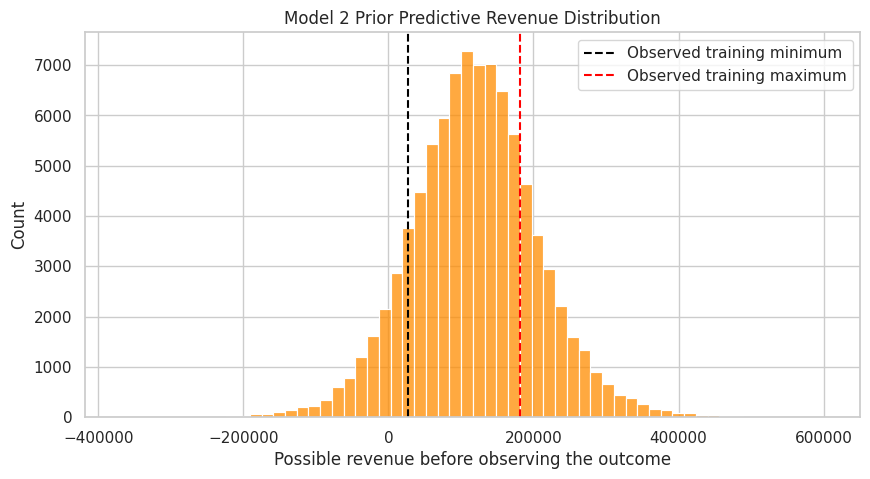

In [30]:
# %% 15 - Model 2 prior predictive check

import inspect

with mmm_model_2:

    prior_argument = (
        "draws"
        if "draws" in inspect.signature(
            pm.sample_prior_predictive
        ).parameters
        else "samples"
    )

    prior_idata_model_2 = (
        pm.sample_prior_predictive(
            **{prior_argument: 300},
            random_seed=SEED
        )
    )

# --------------------------------------------------
# Access prior predictive results
# --------------------------------------------------

prior_group_model_2 = (
    prior_idata_model_2.prior_predictive
)

if hasattr(
    prior_group_model_2,
    "dataset"
):
    prior_group_model_2 = (
        prior_group_model_2.dataset
    )

prior_scaled_model_2 = (
    prior_group_model_2[
        "revenue_likelihood"
    ]
    .values
    .reshape(-1)
)

# Convert back into raw revenue
prior_revenue_model_2 = (
    y_mean_model_2
    + y_sd_model_2
    * prior_scaled_model_2
)

# --------------------------------------------------
# Summarize the possible prior outcomes
# --------------------------------------------------

prior_summary_model_2 = pd.Series({
    "P05": np.quantile(
        prior_revenue_model_2,
        0.05
    ),
    "Median": np.quantile(
        prior_revenue_model_2,
        0.50
    ),
    "P95": np.quantile(
        prior_revenue_model_2,
        0.95
    ),
    "Minimum":
        prior_revenue_model_2.min(),
    "Maximum":
        prior_revenue_model_2.max()
})

print("Observed Model 2 training revenue range:")

print(
    f"${y_raw_model_2[train_mask].min():,.0f}"
    f" to "
    f"${y_raw_model_2[train_mask].max():,.0f}"
)

print("\nModel 2 prior-predictive revenue:")

display(
    prior_summary_model_2
    .to_frame("Revenue")
    .round(2)
)

# --------------------------------------------------
# Plot
# --------------------------------------------------

plt.figure(figsize=(10, 5))

sns.histplot(
    prior_revenue_model_2,
    bins=60,
    color="darkorange"
)

plt.axvline(
    y_raw_model_2[train_mask].min(),
    color="black",
    linestyle="--",
    label="Observed training minimum"
)

plt.axvline(
    y_raw_model_2[train_mask].max(),
    color="red",
    linestyle="--",
    label="Observed training maximum"
)

plt.title(
    "Model 2 Prior Predictive Revenue Distribution"
)

plt.xlabel(
    "Possible revenue before observing the outcome"
)

plt.ylabel("Count")
plt.legend()
plt.show()

#Run Model 2 with GPU MCMC

In [31]:
# %% 16 - Model 2 GPU MCMC

from pymc.sampling.jax import (
    sample_numpyro_nuts
)

with mmm_model_2:

    idata_model_2 = sample_numpyro_nuts(
        draws=1000,
        tune=2500,
        chains=4,
        target_accept=0.99,
        random_seed=SEED,
        chain_method="vectorized",
        postprocessing_backend="cpu"
    )

print("Model 2 GPU MCMC completed.")

sample: 100%|██████████| 3500/3500 [21:26<00:00,  2.72it/s]


Model 2 GPU MCMC completed.


#Save and diagnose Model 2

In [32]:
# %% 17 - Save Model 2 posterior

idata_model_2.to_netcdf(
    "hierarchical_mmm_model_2.nc"
)

print("Model 2 posterior saved.")

Model 2 posterior saved.


In [33]:
# %% 17B - Model 2 convergence diagnostics

model_2_summary_variables = [
    "intercept_global",
    "sd_show",
    "sd_show_season",
    "alpha",
    "half_saturation",
    "beta_global",
    "sd_log_beta_show",
    "beta_controls",
    "sigma"
]

model_2_convergence_summary = az.summary(
    idata_model_2,
    var_names=model_2_summary_variables,
    round_to=3
)

display(model_2_convergence_summary)

# --------------------------------------------------
# Extract convergence measurements
# --------------------------------------------------

model_2_maximum_rhat = (
    model_2_convergence_summary["r_hat"].max()
)

model_2_minimum_bulk_ess = (
    model_2_convergence_summary["ess_bulk"].min()
)

model_2_minimum_tail_ess = (
    model_2_convergence_summary["ess_tail"].min()
)

model_2_sample_stats = (
    idata_model_2.sample_stats
)

if hasattr(
    model_2_sample_stats,
    "dataset"
):
    model_2_sample_stats = (
        model_2_sample_stats.dataset
    )

model_2_divergences = int(
    model_2_sample_stats[
        "diverging"
    ].sum()
)

print(
    "Maximum R-hat:",
    round(model_2_maximum_rhat, 3)
)

print(
    "Minimum bulk ESS:",
    round(model_2_minimum_bulk_ess)
)

print(
    "Minimum tail ESS:",
    round(model_2_minimum_tail_ess)
)

print(
    "Total divergences:",
    model_2_divergences
)

# --------------------------------------------------
# Automated interpretation
# --------------------------------------------------

if model_2_maximum_rhat <= 1.01:
    print("R-hat check: PASSED")
else:
    print("R-hat check: NEEDS ATTENTION")

if model_2_minimum_bulk_ess >= 400:
    print("Bulk ESS check: PASSED")
else:
    print("Bulk ESS check: NEEDS ATTENTION")

if model_2_divergences == 0:
    print("Divergence check: PASSED")
else:
    print("Divergence check: NEEDS ATTENTION")

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
intercept_global,-2.066,0.295,-2.635,-1.510,0.009,0.006,1168.571,1674.730,1.003
sd_show,0.574,0.259,0.112,1.086,0.008,0.005,843.602,825.635,1.004
sd_show_season,0.038,0.044,0.000,0.115,0.002,0.003,738.541,611.701,1.004
alpha[Network TV],0.698,0.071,0.566,0.838,0.003,0.002,833.119,893.387,1.002
alpha[Cable TV],0.699,0.088,0.533,0.866,0.003,0.001,991.930,2066.413,1.002
alpha[Digital],0.821,0.091,0.660,0.983,0.002,0.001,2324.550,2491.595,1.003
half_saturation[Network TV],1.779,0.649,0.753,3.076,0.015,0.012,1683.581,2237.561,1.003
half_saturation[Cable TV],1.232,0.465,0.468,2.082,0.011,0.012,1806.593,2870.192,1.001
half_saturation[Digital],0.531,0.221,0.196,0.932,0.005,0.006,2414.698,2476.848,1.001
beta_global[Network TV],1.934,0.764,0.654,3.360,0.019,0.016,1491.897,1929.727,1.002


Maximum R-hat: 1.004
Minimum bulk ESS: 739
Minimum tail ESS: 612
Total divergences: 0
R-hat check: PASSED
Bulk ESS check: PASSED
Divergence check: PASSED


LATEST-SEASON TEST SET BY SHOW
--------------------------------


,Show,Season,Observations,First_Week,Last_Week,Episode_Types
0,Show1,5,15,1,15,"Finale, PreLaunch, Premiere, Regular"
1,Show2,5,15,1,15,"Finale, PreLaunch, Premiere, Regular"
2,Show3,5,15,1,15,"Finale, PreLaunch, Premiere, Regular"
3,Show4,5,15,1,15,"Finale, PreLaunch, Premiere, Regular"
4,Show5,2,15,1,15,"Finale, PreLaunch, Premiere, Regular"
5,Show6,2,15,1,15,"Finale, PreLaunch, Premiere, Regular"
6,Show7,2,15,1,15,"Finale, PreLaunch, Premiere, Regular"
7,Show8,2,15,1,15,"Finale, PreLaunch, Premiere, Regular"


Number of test shows: 8
Total test observations: 120
Posterior expected-revenue matrix: (4000, 420)
Posterior predictive matrix: (4000, 420)

MODEL PERFORMANCE
-----------------


,Model,Test_R2,Test_RMSE,Test_MAE
0,Historical show mean,0.837,16360.151,11778.469
1,Historical show-week lifecycle mean,0.946,9442.628,7490.644
2,Hierarchical Bayesian MMM,0.921,11407.486,8759.267


Model 2 90% posterior predictive coverage: 95.0%

ROW-LEVEL LATEST-SEASON PREDICTIONS
-----------------------------------


,Show,Season,Week_Number,Episode_Type,Revenue,Predicted_Mean,Predictive_P05,Predictive_Median,Predictive_P95,Signed_Error,Absolute_Error,Absolute_Percentage_Error,Covered
60,Show1,5,1,PreLaunch,82494.87,78224.16,64052.21,78341.94,92585.72,-4270.71,4270.71,5.18,True
61,Show1,5,2,PreLaunch,98478.75,92786.68,78032.72,92997.77,106601.16,-5692.07,5692.07,5.78,True
62,Show1,5,3,PreLaunch,106711.90,102372.77,88639.05,102571.64,115801.86,-4339.13,4339.13,4.07,True
63,Show1,5,4,PreLaunch,127587.97,115244.51,100369.55,115689.50,129333.94,-12343.46,12343.46,9.67,True
64,Show1,5,5,PreLaunch,130149.12,120957.18,106409.47,121228.62,135226.94,-9191.94,9191.94,7.06,True
65,Show1,5,6,Premiere,134616.29,135227.81,120661.21,135490.35,148969.13,611.52,611.52,0.45,True
66,Show1,5,7,Regular,144373.79,138680.65,123186.34,139012.98,153447.96,-5693.14,5693.14,3.94,True
67,Show1,5,8,Regular,148031.36,144285.84,129304.39,144845.65,158612.48,-3745.52,3745.52,2.53,True
68,Show1,5,9,Regular,152942.34,150114.80,135208.34,150333.74,164279.66,-2827.55,2827.55,1.85,True
69,Show1,5,10,Regular,147002.84,153278.38,138457.63,153566.84,167292.88,6275.54,6275.54,4.27,True



PERFORMANCE BY SHOW
-------------------


,Show,Observations,Mean_Actual_Revenue,Mean_Predicted_Revenue,Mean_Bias,MAE,RMSE,Median_Percentage_Error,Coverage
2,Show3,15,130543.968,108670.856,-21873.112,21873.112,22619.864,18.117,1.000
7,Show8,15,105176.676,96271.586,-8905.090,10156.247,12003.326,8.266,1.000
4,Show5,15,55999.777,63721.167,7721.390,8392.517,10587.102,10.716,0.800
5,Show6,15,117495.933,123137.130,5641.197,6751.239,8675.096,3.400,1.000
3,Show4,15,55202.428,59377.611,4175.183,6939.607,8301.075,13.537,0.933
0,Show1,15,130135.460,129955.513,-179.947,6233.855,7063.738,4.722,1.000
6,Show7,15,37839.780,41367.982,3528.202,5161.423,6997.720,9.573,0.867
1,Show2,15,44296.310,43779.691,-516.619,4566.139,5494.680,8.251,1.000



PERFORMANCE BY EPISODE TYPE
---------------------------


,Episode_Type,Observations,Mean_Bias,MAE,RMSE,Median_Percentage_Error,Coverage
2,Premiere,8,-4858.542,8573.771,12726.542,6.136,1.000
1,PreLaunch,40,-2454.818,8668.584,11599.978,9.378,0.975
3,Regular,64,-1.138,9085.530,11352.095,9.652,0.922
0,Finale,8,-2374.758,6788.078,9286.455,5.805,1.000


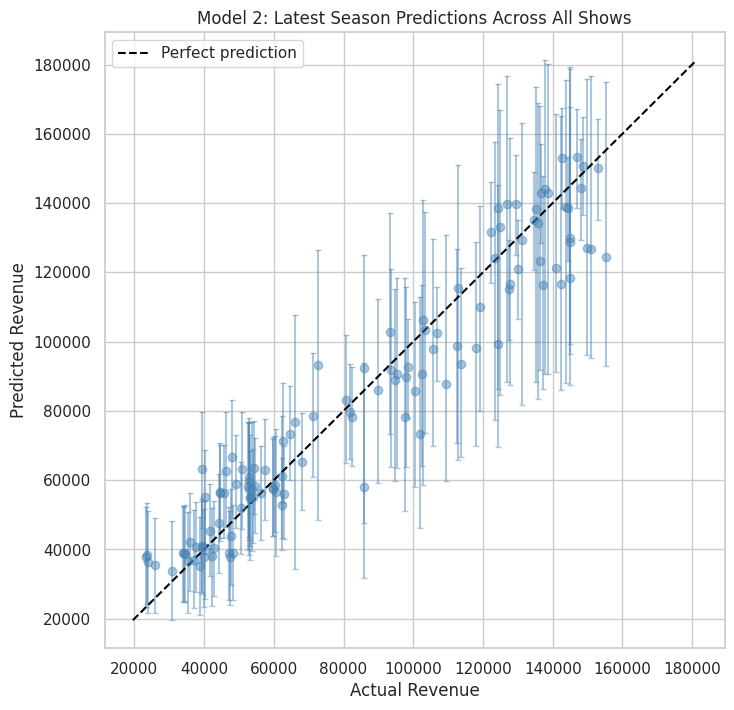


ERROR DISTRIBUTION
------------------


,Value
Median Absolute Error,6560.77
P75 Absolute Error,12285.10
P90 Absolute Error,20143.24
P95 Absolute Error,24490.78
Maximum Absolute Error,30931.85
Median Percentage Error,8.73
P90 Percentage Error,26.67


In [34]:
# %% 18 - Complete Model 2 mixed-show prediction and evaluation

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

# =========================================================
# PART 1 — Verify that the test set contains all shows
# =========================================================

test_show_mix = (
    df.loc[test_mask]
    .groupby(["Show", "Season"])
    .agg(
        Observations=(
            "Week_Number",
            "size"
        ),
        First_Week=(
            "Week_Number",
            "min"
        ),
        Last_Week=(
            "Week_Number",
            "max"
        ),
        Episode_Types=(
            "Episode_Type",
            lambda values:
                ", ".join(
                    sorted(values.unique())
                )
        )
    )
    .reset_index()
)

print("LATEST-SEASON TEST SET BY SHOW")
print("--------------------------------")

display(test_show_mix)

print(
    "Number of test shows:",
    test_show_mix["Show"].nunique()
)

print(
    "Total test observations:",
    test_mask.sum()
)

# Safety checks
assert (
    test_show_mix["Show"].nunique()
    == df["Show"].nunique()
), "Not all shows are represented in testing."

assert (
    test_show_mix["Observations"] == 15
).all(), "Every test show-season should contain 15 weeks."

# =========================================================
# PART 2 — Access Model 2 posterior draws
# =========================================================

posterior_model_2 = (
    idata_model_2.posterior
)

# Compatibility with newer DataTree results
if hasattr(
    posterior_model_2,
    "dataset"
):
    posterior_model_2 = (
        posterior_model_2.dataset
    )

# Expected standardized revenue:
# posterior samples × all 420 observations
posterior_mu_scaled_model_2 = (
    posterior_model_2["mu_all"]
    .stack(sample=("chain", "draw"))
    .transpose("sample", "obs")
    .values
)

print(
    "Posterior expected-revenue matrix:",
    posterior_mu_scaled_model_2.shape
)

# Convert standardized predictions back into dollars
posterior_mu_raw_model_2 = (
    y_mean_model_2
    + y_sd_model_2
    * posterior_mu_scaled_model_2
)

# Mean expected revenue across all posterior draws
posterior_mean_model_2 = (
    posterior_mu_raw_model_2.mean(axis=0)
)

# =========================================================
# PART 3 — Add unexplained revenue variation
# =========================================================

posterior_sigma_scaled_model_2 = (
    posterior_model_2["sigma"]
    .stack(sample=("chain", "draw"))
    .transpose("sample")
    .values
)

posterior_sigma_raw_model_2 = (
    posterior_sigma_scaled_model_2
    * y_sd_model_2
)

rng_model_2 = np.random.default_rng(
    SEED
)

# Each posterior parameter draw generates
# one possible observed revenue for each row
posterior_predictive_model_2 = (
    rng_model_2.normal(
        loc=posterior_mu_raw_model_2,
        scale=posterior_sigma_raw_model_2[
            :, None
        ]
    )
)

print(
    "Posterior predictive matrix:",
    posterior_predictive_model_2.shape
)

# =========================================================
# PART 4 — Extract latest-season test predictions
# =========================================================

test_actual_model_2 = (
    y_raw_model_2[test_mask]
)

test_prediction_model_2 = (
    posterior_mean_model_2[test_mask]
)

test_predictive_draws_model_2 = (
    posterior_predictive_model_2[
        :,
        test_mask
    ]
)

test_p05_model_2 = np.quantile(
    test_predictive_draws_model_2,
    0.05,
    axis=0
)

test_median_model_2 = np.quantile(
    test_predictive_draws_model_2,
    0.50,
    axis=0
)

test_p95_model_2 = np.quantile(
    test_predictive_draws_model_2,
    0.95,
    axis=0
)

# =========================================================
# PART 5 — Bayesian Model 2 metrics
# =========================================================

model_2_r2 = r2_score(
    test_actual_model_2,
    test_prediction_model_2
)

model_2_rmse = (
    mean_squared_error(
        test_actual_model_2,
        test_prediction_model_2
    ) ** 0.5
)

model_2_mae = mean_absolute_error(
    test_actual_model_2,
    test_prediction_model_2
)

model_2_coverage = np.mean(
    (
        test_actual_model_2
        >= test_p05_model_2
    )
    &
    (
        test_actual_model_2
        <= test_p95_model_2
    )
)

# =========================================================
# PART 6 — Baseline 1: historical show mean
# =========================================================

show_mean_baseline_table = (
    df.loc[train_mask]
    .groupby("Show")[TARGET]
    .mean()
    .rename("Show_Mean_Baseline")
    .reset_index()
)

show_mean_predictions = (
    df.loc[
        test_mask,
        ["Show"]
    ]
    .merge(
        show_mean_baseline_table,
        on="Show",
        how="left"
    )["Show_Mean_Baseline"]
    .to_numpy()
)

# =========================================================
# PART 7 — Baseline 2: historical show-week mean
# =========================================================

# This benchmark predicts each lifecycle week using
# the same show's average revenue at that week
# across earlier completed seasons.

show_week_baseline_table = (
    df.loc[train_mask]
    .groupby(
        ["Show", "Week_Number"]
    )[TARGET]
    .mean()
    .rename("Show_Week_Baseline")
    .reset_index()
)

show_week_predictions = (
    df.loc[
        test_mask,
        ["Show", "Week_Number"]
    ]
    .merge(
        show_week_baseline_table,
        on=[
            "Show",
            "Week_Number"
        ],
        how="left"
    )["Show_Week_Baseline"]
    .to_numpy()
)

# Confirm all benchmark predictions exist
assert not np.isnan(
    show_mean_predictions
).any()

assert not np.isnan(
    show_week_predictions
).any()

# =========================================================
# PART 8 — Compare models
# =========================================================

model_2_performance = pd.DataFrame({
    "Model": [
        "Historical show mean",
        "Historical show-week lifecycle mean",
        "Hierarchical Bayesian MMM"
    ],

    "Test_R2": [
        r2_score(
            test_actual_model_2,
            show_mean_predictions
        ),

        r2_score(
            test_actual_model_2,
            show_week_predictions
        ),

        model_2_r2
    ],

    "Test_RMSE": [
        mean_squared_error(
            test_actual_model_2,
            show_mean_predictions
        ) ** 0.5,

        mean_squared_error(
            test_actual_model_2,
            show_week_predictions
        ) ** 0.5,

        model_2_rmse
    ],

    "Test_MAE": [
        mean_absolute_error(
            test_actual_model_2,
            show_mean_predictions
        ),

        mean_absolute_error(
            test_actual_model_2,
            show_week_predictions
        ),

        model_2_mae
    ]
})

print("\nMODEL PERFORMANCE")
print("-----------------")

display(
    model_2_performance.round(3)
)

print(
    "Model 2 90% posterior predictive coverage:",
    f"{model_2_coverage:.1%}"
)

# =========================================================
# PART 9 — Create row-level test results
# =========================================================

test_results_model_2 = df.loc[
    test_mask,
    [
        "Show",
        "Season",
        "Week_Number",
        "Episode_Type",
        TARGET
    ]
].copy()

test_results_model_2[
    "Predicted_Mean"
] = test_prediction_model_2

test_results_model_2[
    "Predictive_P05"
] = test_p05_model_2

test_results_model_2[
    "Predictive_Median"
] = test_median_model_2

test_results_model_2[
    "Predictive_P95"
] = test_p95_model_2

test_results_model_2[
    "Signed_Error"
] = (
    test_results_model_2[
        "Predicted_Mean"
    ]
    - test_results_model_2[TARGET]
)

test_results_model_2[
    "Absolute_Error"
] = np.abs(
    test_results_model_2[
        "Signed_Error"
    ]
)

test_results_model_2[
    "Absolute_Percentage_Error"
] = (
    test_results_model_2[
        "Absolute_Error"
    ]
    / test_results_model_2[TARGET]
    * 100
)

test_results_model_2[
    "Covered"
] = (
    (
        test_results_model_2[TARGET]
        >= test_results_model_2[
            "Predictive_P05"
        ]
    )
    &
    (
        test_results_model_2[TARGET]
        <= test_results_model_2[
            "Predictive_P95"
        ]
    )
)

print("\nROW-LEVEL LATEST-SEASON PREDICTIONS")
print("-----------------------------------")

display(
    test_results_model_2
    .head(20)
    .round(2)
)

# =========================================================
# PART 10 — Performance by show
# =========================================================

performance_by_show_model_2 = (
    test_results_model_2
    .groupby("Show")
    .agg(
        Observations=(
            TARGET,
            "size"
        ),

        Mean_Actual_Revenue=(
            TARGET,
            "mean"
        ),

        Mean_Predicted_Revenue=(
            "Predicted_Mean",
            "mean"
        ),

        Mean_Bias=(
            "Signed_Error",
            "mean"
        ),

        MAE=(
            "Absolute_Error",
            "mean"
        ),

        RMSE=(
            "Signed_Error",
            lambda errors:
                np.sqrt(
                    np.mean(errors ** 2)
                )
        ),

        Median_Percentage_Error=(
            "Absolute_Percentage_Error",
            "median"
        ),

        Coverage=(
            "Covered",
            "mean"
        )
    )
    .reset_index()
    .sort_values(
        "RMSE",
        ascending=False
    )
)

print("\nPERFORMANCE BY SHOW")
print("-------------------")

display(
    performance_by_show_model_2.round(3)
)

# =========================================================
# PART 11 — Performance by episode type
# =========================================================

performance_by_episode_model_2 = (
    test_results_model_2
    .groupby("Episode_Type")
    .agg(
        Observations=(
            TARGET,
            "size"
        ),

        Mean_Bias=(
            "Signed_Error",
            "mean"
        ),

        MAE=(
            "Absolute_Error",
            "mean"
        ),

        RMSE=(
            "Signed_Error",
            lambda errors:
                np.sqrt(
                    np.mean(errors ** 2)
                )
        ),

        Median_Percentage_Error=(
            "Absolute_Percentage_Error",
            "median"
        ),

        Coverage=(
            "Covered",
            "mean"
        )
    )
    .reset_index()
    .sort_values(
        "RMSE",
        ascending=False
    )
)

print("\nPERFORMANCE BY EPISODE TYPE")
print("---------------------------")

display(
    performance_by_episode_model_2.round(3)
)

# =========================================================
# PART 12 — Actual versus predicted chart
# =========================================================

plt.figure(figsize=(8, 8))

plt.errorbar(
    test_actual_model_2,
    test_prediction_model_2,
    yerr=[
        test_prediction_model_2
        - test_p05_model_2,

        test_p95_model_2
        - test_prediction_model_2
    ],
    fmt="o",
    alpha=0.45,
    capsize=2,
    color="steelblue"
)

chart_minimum = min(
    test_actual_model_2.min(),
    test_p05_model_2.min()
)

chart_maximum = max(
    test_actual_model_2.max(),
    test_p95_model_2.max()
)

plt.plot(
    [chart_minimum, chart_maximum],
    [chart_minimum, chart_maximum],
    linestyle="--",
    color="black",
    label="Perfect prediction"
)

plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title(
    "Model 2: Latest Season Predictions Across All Shows"
)
plt.legend()
plt.show()

# =========================================================
# PART 13 — Error distribution
# =========================================================

error_distribution_model_2 = pd.Series({
    "Median Absolute Error":
        test_results_model_2[
            "Absolute_Error"
        ].median(),

    "P75 Absolute Error":
        test_results_model_2[
            "Absolute_Error"
        ].quantile(0.75),

    "P90 Absolute Error":
        test_results_model_2[
            "Absolute_Error"
        ].quantile(0.90),

    "P95 Absolute Error":
        test_results_model_2[
            "Absolute_Error"
        ].quantile(0.95),

    "Maximum Absolute Error":
        test_results_model_2[
            "Absolute_Error"
        ].max(),

    "Median Percentage Error":
        test_results_model_2[
            "Absolute_Percentage_Error"
        ].median(),

    "P90 Percentage Error":
        test_results_model_2[
            "Absolute_Percentage_Error"
        ].quantile(0.90)
})

print("\nERROR DISTRIBUTION")
print("------------------")

display(
    error_distribution_model_2
    .to_frame("Value")
    .round(2)
)

In [35]:
# %% Diagnose latest-season level shifts by show

historical_show_revenue = (
    df.loc[train_mask]
    .groupby("Show")[TARGET]
    .mean()
    .rename("Earlier_Season_Mean")
    .reset_index()
)

latest_show_revenue = (
    df.loc[test_mask]
    .groupby("Show")[TARGET]
    .mean()
    .rename("Latest_Season_Mean")
    .reset_index()
)

show_level_shift = (
    historical_show_revenue
    .merge(
        latest_show_revenue,
        on="Show"
    )
)

show_level_shift["Latest_minus_Historical"] = (
    show_level_shift["Latest_Season_Mean"]
    - show_level_shift["Earlier_Season_Mean"]
)

show_level_shift["Percent_Shift"] = (
    show_level_shift["Latest_minus_Historical"]
    / show_level_shift["Earlier_Season_Mean"]
    * 100
)

display(
    show_level_shift
    .sort_values(
        "Percent_Shift",
        ascending=False
    )
    .round(2)
)

,Show,Earlier_Season_Mean,Latest_Season_Mean,Latest_minus_Historical,Percent_Shift
7,Show8,104840.42,105176.68,336.26,0.32
1,Show2,44622.96,44296.31,-326.65,-0.73
2,Show3,132354.84,130543.97,-1810.87,-1.37
3,Show4,56698.34,55202.43,-1495.91,-2.64
0,Show1,136927.06,130135.46,-6791.60,-4.96
5,Show6,127020.37,117495.93,-9524.43,-7.50
4,Show5,60614.17,55999.78,-4614.39,-7.61
6,Show7,41902.65,37839.78,-4062.87,-9.70


###I built a hierarchical Bayesian MMM across 420 observations, eight shows, and 28 show-seasons. The model combined geometric adstock, Hill saturation, show-level media effects, show-season baselines, and controls such as Holiday, Lead-in Bonus, lifecycle week, and episode type. Instead of producing one coefficient per channel, MCMC generated 4,000 plausible parameter combinations and carried that uncertainty into predictions.

###The first temporal split looked sensible but created a hidden problem: training ended at Week 12 and contained no Finales, while testing covered Weeks 13–15 and was 33% Finales. Although the model achieved a test R² of 0.892 and reduced RMSE by 21% versus the baseline, its 90% intervals covered only 82.1% of outcomes.

###I retained this as an extrapolation stress test and redesigned validation using complete earlier seasons for training and each show’s latest season for testing. The revised model reached a maximum R-hat of 1.004 with zero divergences. Its median absolute error was $6,561, or 8.73%, while the analysis also revealed meaningful tail risk and a large unseen baseline shift for Show3.

###The main lesson was that a technically correct model can still answer only a partial business question. Validation must reflect when predictions are made, what historical information is available, and whether training contains comparable lifecycle situations.